In [54]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

##open photos
photo_folder = 'output_folder' ##replace path with path to folder with photos to process
photos = []
undistorted_photos = []
num_photos = len(os.listdir(photo_folder))

##open .csv file with pose and timestep
pose_file = 'lab3_pose.csv' ##replace with path to .csv file with pose and timestep data
pose_data = np.genfromtxt(pose_file, delimiter=',', skip_header=1)
#1-idx, 2-px, 3-py, 4-pz, 5-qw, 6-qx, 7-qy, 8-qz
# print(f"pose data: {pose_data[8:12]}") ##check data input is correct from csv file
##landmark pixel coordinates
##must be within x=y= {-2, 2} [m] in body frame
landmark_px = []
landmark_body = []

In [3]:
##camera parameters from lab 3 document on quercus
K = np.matrix([[698.86, 0, 306.91],[0, 699.13, 150.34],[0, 0, 1]])
d = np.array([0.191887, -0.563680, -0.003676, -0.002037, 0])
Tcb = np.matrix([[1, -1, 0, 0],[-1, 0, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])
Rcb = Tcb[:3, :3]

In [44]:
##loop through photos to undistort and find contours of landmarks
thresh_photos = [] ##clear cache
undistorted_photos = [] ##clear cache

test_img = (512, 513, 514, 515, 516) ##indices of photos to test contour detection on
test_inner = 0
for i in test_img:
    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{i}.jpg')
    photo = cv2.imread(photo_path)
    photos.append(photo)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask
    # Adjust 200 based on your lighting; pixels above 200 become white (255)
    ret, thresh = cv2.threshold(photo, 120, 255, cv2.THRESH_BINARY)
    thresh_photos.append(thresh)



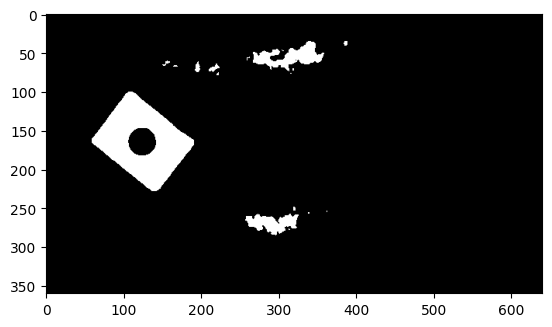

In [45]:
imgbrg = thresh_photos[test_inner]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
plt.show()

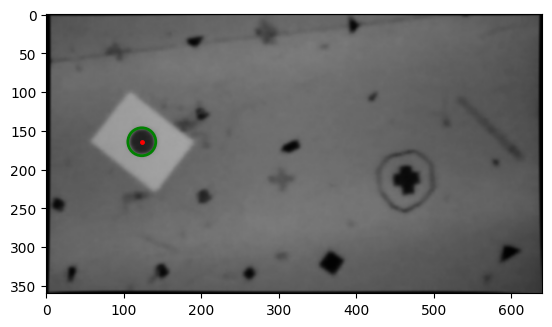

In [46]:
## find contour, identify circle, then plot the circle on the undistored photo
contours, hierarchy = cv2.findContours(thresh_photos[test_inner], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
imgbrg = undistorted_photos[test_inner]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
if hierarchy is not None and len(contours) > 0:
    for i, contour in enumerate(contours):
        
        # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
        # We want to look at the 'Parent' index (which is at index 3)
        parent_idx = hierarchy[0][i][3]
        
        # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
        if parent_idx != -1:
            
            # 5. Filter out tiny specks of noise that might be inside the square
            if cv2.contourArea(contour) > 50: 
                
                # We found the inner dot! Calculate its circle.
                (x, y), radius = cv2.minEnclosingCircle(contour)
                center = (int(x), int(y))
                radius = int(radius)
                landmark_px.append(center)
                
                # draw the circle with matplotlib instead of cv2
                # (assumes the image has already been shown with plt.imshow
                #  – you can call plt.show() again after the loop to render
                #  the patches)
                circ = plt.Circle(center, radius,
                                  edgecolor='g', facecolor='none', linewidth=2)
                plt.gca().add_patch(circ)

                # optional: mark the exact centre with a red dot
                plt.plot(center[0], center[1], 'r.', markersize=5)

plt.show()

Processing image index: 25.0


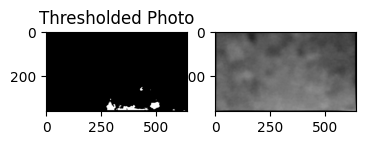

Processing image index: 131.14814814814815
Skipping image


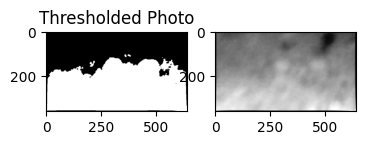

Processing image index: 237.2962962962963


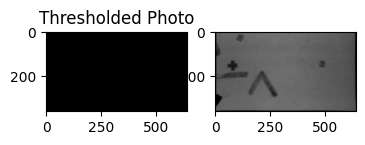

Processing image index: 343.44444444444446


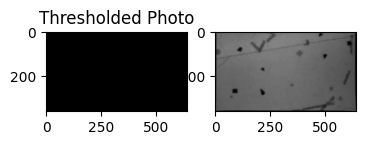

Processing image index: 449.5925925925926


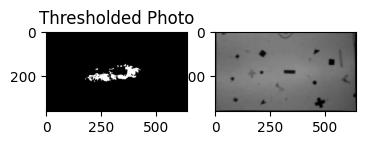

Processing image index: 555.7407407407408


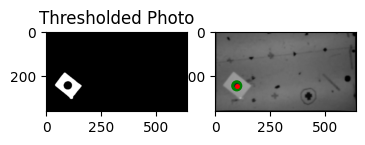

Processing image index: 661.8888888888889


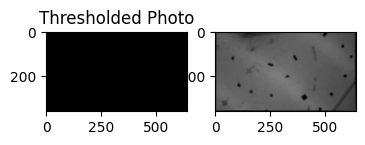

Processing image index: 768.0370370370371


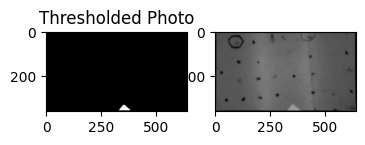

Processing image index: 874.1851851851852


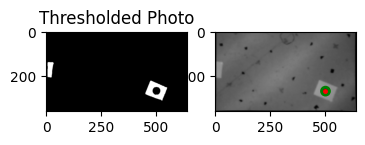

Processing image index: 980.3333333333334


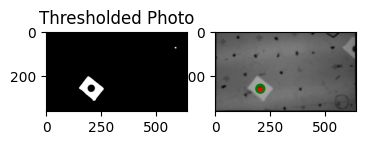

Processing image index: 1086.4814814814815


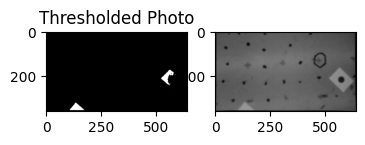

Processing image index: 1192.6296296296296


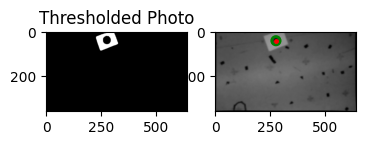

Processing image index: 1298.7777777777778


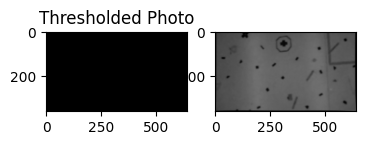

Processing image index: 1404.925925925926


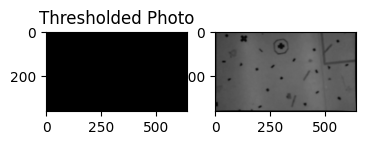

Processing image index: 1511.0740740740741


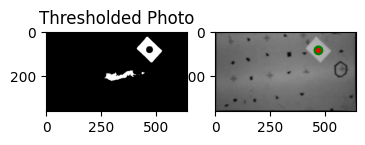

Processing image index: 1617.2222222222222


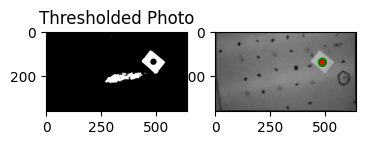

Processing image index: 1723.3703703703704


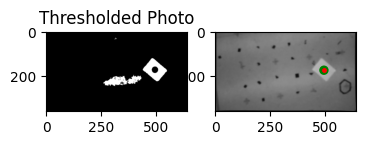

Processing image index: 1829.5185185185187


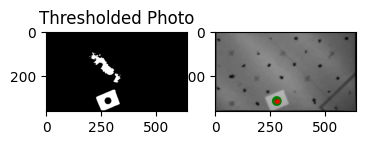

Processing image index: 1935.6666666666667


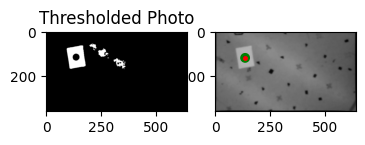

Processing image index: 2041.8148148148148


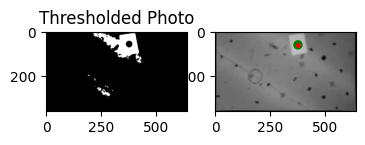

Processing image index: 2147.962962962963


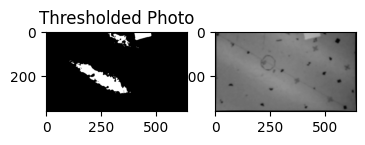

Processing image index: 2254.1111111111113


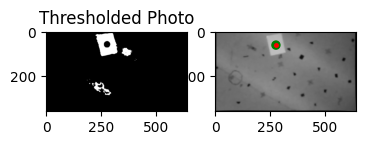

Processing image index: 2360.259259259259


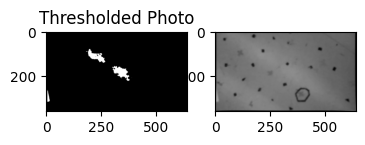

Processing image index: 2466.4074074074074


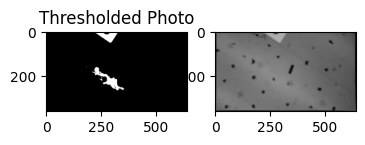

Processing image index: 2572.5555555555557


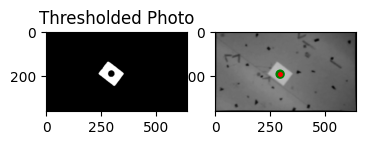

Processing image index: 2678.703703703704


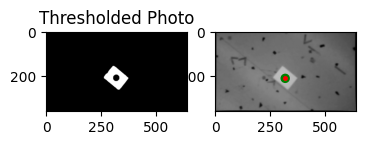

Processing image index: 2784.851851851852


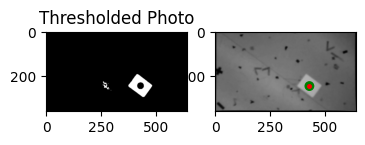

Processing image index: 2891.0


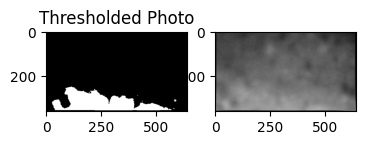

In [138]:
###ALL IN ONE MULTI PLOT VIEWER BABY
##loop through photos to undistort and find contours of landmarks
#880, 512, 2696, 850, 2825
testing = np.linspace(25, 2891, 28)
# testing = np.linspace(2250,2407, 18) #indices of photos to test contour detection on
test_inner = 0
threshold = 137
size = 500
def plot_photos_with_contours(test_img, test_inner):
    thresh_photos = [] ##clear cache
    undistorted_photos = [] ##clear cache
    print(f"Processing image index: {test_img}")

    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{int(test_img)}.jpg')
    photo = cv2.imread(photo_path)
    photos.append(photo)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask
    # Adjust 200 based on your lighting; pixels above 200 become white (255)
    ret, thresh = cv2.threshold(photo, threshold, 255, cv2.THRESH_BINARY)
    thresh_photos.append(thresh)
    #prepare 2 plots to show the undistorted photo and the thresholded photo side by side
    fig, axs = plt.subplots(1, 2, figsize=(4, 6))
    #plot thresh photo on left
    imgbrg = thresh_photos[test_inner]
    imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
    axs[0].imshow(imgrgb)
    axs[0].set_title('Thresholded Photo')


    ## find contour, identify circle, then plot the circle on the undistored photo
    contours, hierarchy = cv2.findContours(thresh_photos[test_inner], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if np.sum(thresh == 255) > 0.5 * thresh.size:
        print("Skipping image")
        hierarchy = None
    imgbrg = undistorted_photos[test_inner]
    imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
    plt.imshow(imgrgb)
    if hierarchy is not None and len(contours) > 0:
        for i, contour in enumerate(contours):
            
            # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
            # We want to look at the 'Parent' index (which is at index 3)
            parent_idx = hierarchy[0][i][3]
            
            # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
            if parent_idx != -1:
                
                # 5. Filter out tiny specks of noise that might be inside the square
                if cv2.contourArea(contour) > size: 
                    
                    # We found the inner dot! Calculate its circle.
                    (x, y), radius = cv2.minEnclosingCircle(contour)
                    center = (int(x), int(y))
                    radius = int(radius)
                    landmark_px.append(center)
                    
                    # draw the circle with matplotlib instead of cv2
                    # (assumes the image has already been shown with plt.imshow
                    #  – you can call plt.show() again after the loop to render
                    #  the patches)
                    circ = plt.Circle(center, radius,
                                    edgecolor='g', facecolor='none', linewidth=2)
                    plt.gca().add_patch(circ)

                    # optional: mark the exact centre with a red dot
                    plt.plot(center[0], center[1], 'r.', markersize=5)

    #plot undistorted photo on right with circle mapped
    plt.show()
for j in range(len(testing)):
    plot_photos_with_contours(testing[j],test_inner)

Transform images from camera frame to body frame

In [25]:
##load pose
row = 850
def extract_pose_from_csv_row(row):
    # 1. Extract Position
    px, py, pz = row[1], row[2], row[3]
    drone_pos = np.array([px, py, pz])
    
    # 2. Extract Quaternions and REORDER them to [x, y, z, w] for Scipy
    qw, qx, qy, qz = row[4], row[5], row[6], row[7]
    
    # 3. Create the Rotation Matrix
    # scipy expects the format [x, y, z, w]
    rotation = R.from_quat([qx, qy, qz, qw])
    R_body_to_world = rotation.as_matrix() # Returns a 3x3 numpy array
    
    return drone_pos, R_body_to_world
pose_test, Rbw = extract_pose_from_csv_row(pose_data[850])
# print(f"Drone Position (px, py, pz): {pose_test[0], pose_test[1], pose_test[2]}")
# print(f"Rotation Matrix (Body to World):\n{rot_test}")
for i in range(len(landmark_px)):
    print(f"Landmark {i} pixel coordinates: {landmark_px[i]}")
    print(f"Drone Position (px, py, pz): {pose_test[0], pose_test[1], pose_test[2]}")

    ##pixel to camera frame
    uv_vec = np.array([[landmark_px[i][0]], [landmark_px[i][1]], [1.0] ]) ##homogenous pixel coordinates
    ray_c = np.linalg.inv(K) @ uv_vec ##ray direction in camera frame
    # ray_direction = np.linalg.inv(K).dot(np.array([landmark_px[i][0], landmark_px[i][1], 1]))
    #ray_direction = Rcb.T.dot(np.array([landmark_px[i][0], landmark_px[i][1], 1]))

    ##body to world
    rcw = Rbw @ Rcb
    ray_w = rcw @ ray_c
    ray_w_flat = ray_w.flatten() ##flatten to 1D array for easier handling
    print(f"Landmark {i} ray direction in world frame: {ray_w}")

    # Extract the drone's Z altitude and the ray's Z direction
    drone_z = pose_test[2]
    ray_z = ray_w[2]

    # Calculate the scaling factor 's' to reach the ground (where Z = 0)
    s = -drone_z / ray_z 

    # Scale the entire ray vector and add it to the drone's position
    landmark_world_position = pose_test + (s * ray_w_flat)

    # Flatten the final result just to be absolutely safe
    landmark_world_position = np.asarray(landmark_world_position).flatten()# The result is a 3D point: [X, Y, Z]. Z should be very close to 0.
    
    final_x = landmark_world_position[0]
    final_y = landmark_world_position[1]

    print(f"Landmark {i} is located on the ground at: X = {final_x:.3f}m, Y = {final_y:.3f}m Z = {landmark_world_position[2]:.3f}m")
    





Landmark 0 pixel coordinates: (469, 103)
Drone Position (px, py, pz): (np.float64(-0.22717), np.float64(-1.39371), np.float64(2.14137))
Landmark 0 ray direction in world frame: [[ 0.34210488]
 [-0.17532331]
 [-0.99790202]]
Landmark 0 is located on the ground at: X = 0.507m, Y = -1.770m Z = 0.000m


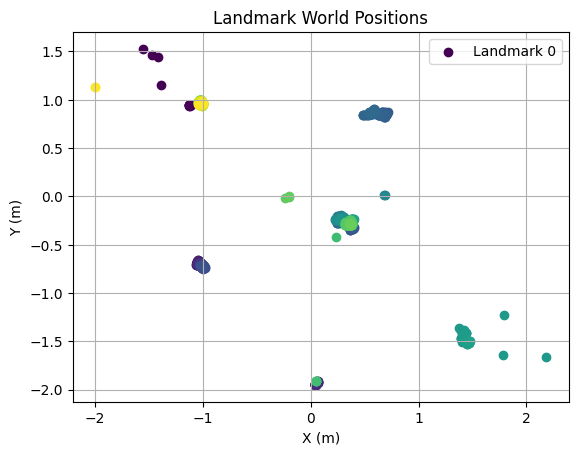

In [125]:
##plot scatter plot of landmark world positions
land = 'landmark_world_coordinates.csv'
landmark_data = np.genfromtxt(land, delimiter=',', skip_header=1)
#scatter them in order of first to last - first blue last red
for i in range(len(landmark_data)):
    plt.scatter(landmark_data[i][0], landmark_data[i][1], color=plt.cm.viridis(i / len(landmark_data)), label=f'Landmark {i}')
    if i==0:
        plt.legend()  
plt.title('Landmark World Positions')
#add scale for colours
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid()
plt.show()

Centroids of the 6 clusters (landmarks):
Landmark 0: X = 1.452m, Y = -1.473m
Landmark 1: X = -1.033m, Y = 0.976m
Landmark 2: X = 0.322m, Y = -0.259m
Landmark 3: X = 0.630m, Y = 0.857m
Landmark 4: X = -1.027m, Y = -0.704m
Landmark 5: X = 0.051m, Y = -1.930m


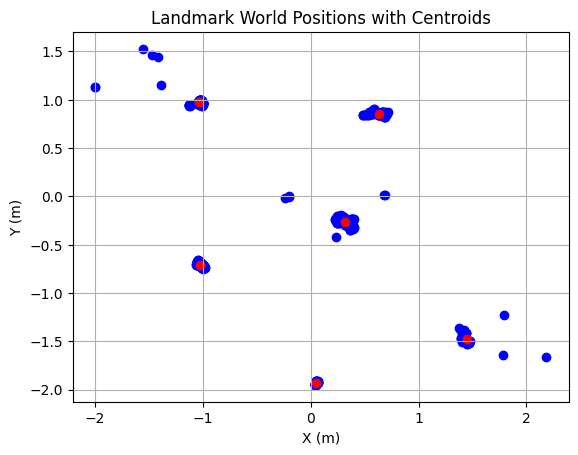

In [139]:
###identify 6 centroids from the scatter plot of landmark world positions and center them
from sklearn.cluster import KMeans
import numpy as np

scatter_x = landmark_data[:, 0]
scatter_y = landmark_data[:, 1]
scatter_points = np.column_stack((scatter_x, scatter_y))
kmeans = KMeans(n_clusters=6, random_state=0).fit(scatter_points)
centroids = kmeans.cluster_centers_
print("Centroids of the 6 clusters (landmarks):")
for idx, centroid in enumerate(centroids):
    print(f"Landmark {idx}: X = {centroid[0]:.3f}m, Y = {centroid[1]:.3f}m")
plt.scatter(scatter_x, scatter_y, color='blue', label='Landmark Points')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', label='Centroids')
plt.title('Landmark World Positions with Centroids')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid()
plt.show()